In [3]:
from transformers import BertForQuestionAnswering
from transformers import BertTokenizer
import torch

In [4]:
model_name = "bert-large-uncased-whole-word-masking-finetuned-squad"

model = BertForQuestionAnswering.from_pretrained(model_name)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/443 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.34G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

BertForQuestionAnswering LOAD REPORT from: bert-large-uncased-whole-word-masking-finetuned-squad
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.bias   | UNEXPECTED |  | 
bert.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [5]:
tokenizer = BertTokenizer.from_pretrained(model_name)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

# **Embeddings**

In [6]:
# example question and text containing the answer
question = "When was the first dvd released?"

answer_document = "The first DVD (Digital Versatile Disc) was released on March 24, 1997. It was a movie titled 'Twister' and was released in Japan."

In [9]:
encoding = tokenizer(
    question,
    answer_document,
    return_tensors="pt",
    truncation=True,
    padding=True
)

print(encoding)

{'input_ids': tensor([[  101,  2043,  2001,  1996,  2034,  4966,  2207,  1029,   102,  1996,
          2034,  4966,  1006,  3617, 22979,  5860,  1007,  2001,  2207,  2006,
          2233,  2484,  1010,  2722,  1012,  2009,  2001,  1037,  3185,  4159,
          1005,  9792,  2121,  1005,  1998,  2001,  2207,  1999,  2900,  1012,
           102]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])}


In [19]:
tokenizer.decode(101)

'[CLS]'

In [20]:
tokenizer.decode(102)

'[SEP]'

In [21]:
inputs = encoding["input_ids"]
token_type_ids = encoding["token_type_ids"]

In [22]:
output = model(
    input_ids = inputs,
    token_type_ids = token_type_ids
)

# **Model output**

In [23]:
start_index = torch.argmax(output.start_logits)
end_index = torch.argmax(output.end_logits)

print(start_index)
print(end_index)

tensor(20)
tensor(23)


In [30]:
# Convert to tokens
tokens = tokenizer.convert_ids_to_tokens(
    encoding["input_ids"][0].tolist()
)



In [31]:
# Get answer span
start_index = torch.argmax(output.start_logits)
end_index = torch.argmax(output.end_logits)


In [32]:

# Convert to clean text
answer = tokenizer.convert_tokens_to_string(
    tokens[start_index:end_index+1]
)

print(answer)

march 24, 1997


In [33]:
import matplotlib as plt
import seaborn as sns

In [34]:
s_scores = output.start_logits.detach().numpy().flatten()
e_scores = output.end_logits.detach().numpy().flatten()

In [35]:
token_labels = []
for (i, token) in enumerate(tokens):
    token_labels.append('{:} - {:>2}'.format(token, i))

/tmp/ipykernel_10226/1538046351.py:2: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="center")


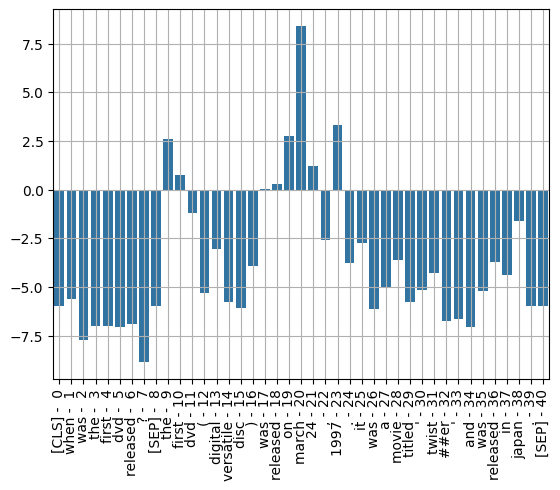

In [36]:
ax = sns.barplot(x=token_labels, y=s_scores)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="center")
ax.grid(True)

/tmp/ipykernel_10226/365763533.py:2: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="center")


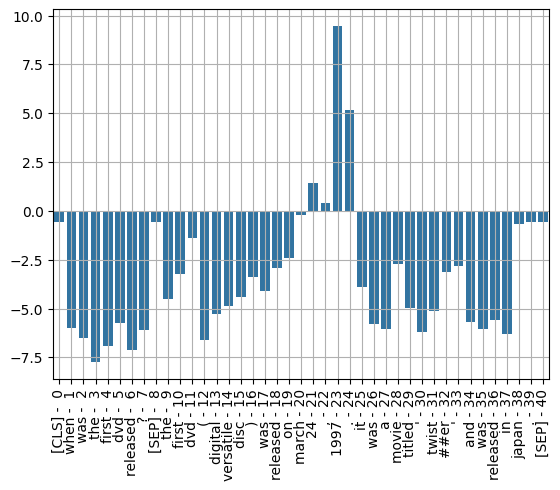

In [37]:
ax = sns.barplot(x=token_labels, y=e_scores)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="center")
ax.grid(True)

# **QA BOT**

In [39]:
sunset_motors_context = """Sunset Motors is a well-established automobile dealership that has been serving customers for over 25 years. Located in a prime commercial area, the dealership offers a wide range of new and pre-owned vehicles from leading global brands. Over the years, it has built a strong reputation for reliability, transparency, and customer satisfaction.

The company provides comprehensive services including vehicle financing, insurance assistance, and certified maintenance support. Their team of experienced professionals ensures that customers receive guidance at every step, from selecting the right vehicle to post-purchase services. Sunset Motors also offers flexible payment plans, making car ownership accessible to a wider audience.

In addition to sales, Sunset Motors has invested heavily in digital transformation by integrating online booking systems, virtual vehicle tours, and AI-driven customer support. This has significantly improved customer experience and operational efficiency. Their commitment to innovation and service excellence has made them a trusted name in the automotive industry."""

print(sunset_motors_context)

Sunset Motors is a well-established automobile dealership that has been serving customers for over 25 years. Located in a prime commercial area, the dealership offers a wide range of new and pre-owned vehicles from leading global brands. Over the years, it has built a strong reputation for reliability, transparency, and customer satisfaction.

The company provides comprehensive services including vehicle financing, insurance assistance, and certified maintenance support. Their team of experienced professionals ensures that customers receive guidance at every step, from selecting the right vehicle to post-purchase services. Sunset Motors also offers flexible payment plans, making car ownership accessible to a wider audience.

In addition to sales, Sunset Motors has invested heavily in digital transformation by integrating online booking systems, virtual vehicle tours, and AI-driven customer support. This has significantly improved customer experience and operational efficiency. Their co

In [43]:
def faq_bot(question):

    context = sunset_motors_context

    input_ids = tokenizer.encode(question, context)
    tokens = tokenizer.convert_ids_to_tokens(input_ids)

    sep_idx = input_ids.index(tokenizer.sep_token_id)
    num_seg_a = sep_idx + 1
    num_seg_b = len(input_ids) - num_seg_a

    segment_ids = [0]*num_seg_a + [1]*num_seg_b

    output = model(torch.tensor([input_ids]), token_type_ids=torch.tensor([segment_ids]))

    answer_start = torch.argmax(output.start_logits)
    answer_end = torch.argmax(output.end_logits)

    if answer_end >= answer_start:
        answer = ' '.join(tokens[answer_start:answer_end+1])
    else:
        print("I don't know how to answer this question, can you ask another one?")
        return None

    corrected_answer = ''
    for word in answer.split():
        if word[0:2] == '##':
            corrected_answer += word[2:]
        else:
            corrected_answer += ' ' + word

    return corrected_answer.strip()

In [44]:
faq_bot("What are the cars available")

'new and pre - owned vehicles from leading global brands'

# **Roberta and DistilBert**

In [45]:
from transformers import RobertaTokenizer, RobertaModel

model_name = "roberta-base"
tokenizer = RobertaTokenizer.from_pretrained(model_name)
model = RobertaModel.from_pretrained(model_name)

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [46]:
from transformers import DistilBertTokenizer, DistilBertModel

model_name = "distilbert-base-uncased"
tokenizer = DistilBertTokenizer.from_pretrained(model_name)
model = DistilBertModel.from_pretrained(model_name)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
